In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [14]:
email_df = pd.read_csv("email_table.csv")
opened_df = pd.read_csv("email_opened_table.csv")
clicked_df = pd.read_csv("link_clicked_table.csv")


In [15]:
email_df['email_opened'] = email_df['email_id'].isin(opened_df['email_id']).astype(int)
email_df['link_clicked'] = email_df['email_id'].isin(clicked_df['email_id']).astype(int)

In [16]:
email_df.to_csv("processed_email_data.csv", index=False)

In [17]:
# ----------------------------------------------
# 6. Feature Engineering (Updated)
# ----------------------------------------------

# Map binary categories
email_df['email_text'] = email_df['email_text'].map({'short': 0, 'long': 1})
email_df['email_version'] = email_df['email_version'].map({'generic': 0, 'personalized': 1})

# Encode 'weekday'
email_df['weekday'] = email_df['weekday'].astype('category').cat.codes

# Create hour_bin
email_df['hour_bin'] = pd.cut(email_df['hour'], bins=[0,6,12,18,24], labels=['night','morning','afternoon','evening'])
email_df['hour_bin'] = email_df['hour_bin'].astype('category').cat.codes

# One-hot encode user_country
email_df = pd.get_dummies(email_df, columns=['user_country'], drop_first=True)


In [18]:
total = len(email_df)
opened = email_df['email_opened'].sum()
clicked = email_df['link_clicked'].sum()

print(f"Opened: {opened/total:.2%}, Clicked: {clicked/total:.2%}")

Opened: 10.35%, Clicked: 2.12%


In [19]:
email_df['email_text'] = email_df['email_text'].map({'short': 0, 'long': 1})
email_df['email_version'] = email_df['email_version'].map({'generic': 0, 'personalized': 1})
email_df['weekday'] = email_df['weekday'].astype('category').cat.codes
email_df['hour_bin'] = pd.cut(email_df['hour'], bins=[0,6,12,18,24], labels=['night','morning','afternoon','evening'])
email_df['hour_bin'] = email_df['hour_bin'].astype('category').cat.codes

In [20]:
features = email_df.drop(columns=['email_id', 'link_clicked'])
labels = email_df['link_clicked']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

In [22]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [23]:
y_pred = model.predict(X_test)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[19420   127]
 [  401    52]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99     19547
           1       0.29      0.11      0.16       453

    accuracy                           0.97     20000
   macro avg       0.64      0.55      0.58     20000
weighted avg       0.96      0.97      0.97     20000



In [24]:
base_ctr = clicked / total
predicted_ctr = model.predict(features).mean()
print(f"\nEstimated Improvement in CTR: {predicted_ctr - base_ctr:.2%}")


Estimated Improvement in CTR: -1.12%


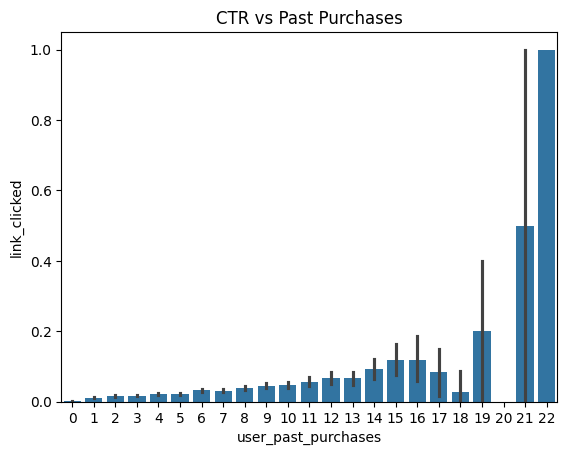

In [27]:
sns.barplot(x='user_past_purchases', y='link_clicked', data=email_df)
plt.title('CTR vs Past Purchases')
plt.show()